## XGBoost Model for Expected Attention

In [70]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [71]:
# load X_train and y_train
X_train = pd.read_csv("../outputs_csv/X_train.csv")
y_original = pd.read_csv("../outputs_csv/y_train.csv")
y_train = y_original["avg_attention_score"]

In [72]:
# implement cross validation using an 80-20 split.
# 5 folds means each validation fold is 20% of the data and each training fold is 80%.
N_SPLITS = 5
RANDOM_STATE = 42

if len(X_train) != len(y_train):
    raise ValueError(
        f"X_train and y_train must have the same number of rows. "
        f"Got {len(X_train)} and {len(y_train)}."
    )

kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_folds = []
for fold_number, (train_idx, val_idx) in enumerate(kfold.split(X_train), start=1):
    cv_folds.append(
        {
            "fold": fold_number,
            "train_idx": train_idx,
            "val_idx": val_idx,
            "X_train_fold": X_train.iloc[train_idx],
            "X_val_fold": X_train.iloc[val_idx],
            "y_train_fold": y_train.iloc[train_idx],
            "y_val_fold": y_train.iloc[val_idx],
        }
    )

cv_summary = pd.DataFrame(
    [
        {
            "fold": fold["fold"],
            "train_rows": len(fold["train_idx"]),
            "validation_rows": len(fold["val_idx"]),
            "validation_pct": len(fold["val_idx"]) / len(X_train),
        }
        for fold in cv_folds
    ]
)

cv_summary

,fold,train_rows,validation_rows,validation_pct
0,1,24776,6195,0.200026
1,2,24777,6194,0.199994
2,3,24777,6194,0.199994
3,4,24777,6194,0.199994
4,5,24777,6194,0.199994


### Creating the Model

In [73]:
try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "xgboost is required for the model cells below. "
        "Install it in this notebook kernel before running these cells."
    ) from exc

N_MONTE_CARLO_SIMULATIONS = 10
MONTE_CARLO_SEEDS = [RANDOM_STATE + seed_offset for seed_offset in range(N_MONTE_CARLO_SIMULATIONS)]


def calculate_regression_metrics(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


def evaluate_xgboost_monte_carlo(model_name, model_params, cv_folds, monte_carlo_seeds):
    fold_metrics = []

    for fold in cv_folds:
        simulation_predictions = []

        for seed in monte_carlo_seeds:
            model = XGBRegressor(**model_params, random_state=seed)
            model.fit(fold["X_train_fold"], fold["y_train_fold"])
            simulation_predictions.append(model.predict(fold["X_val_fold"]))

        averaged_predictions = np.mean(simulation_predictions, axis=0)
        metrics = calculate_regression_metrics(fold["y_val_fold"], averaged_predictions)
        metrics.update(
            {
                "model": model_name,
                "fold": fold["fold"],
                "num_simulations": len(monte_carlo_seeds),
                "mean_prediction_std": np.mean(np.std(simulation_predictions, axis=0)),
            }
        )
        fold_metrics.append(metrics)

    fold_metrics_df = pd.DataFrame(fold_metrics)
    summary = pd.DataFrame(
        [
            {
                "model": model_name,
                "num_simulations": len(monte_carlo_seeds),
                "mean_rmse": fold_metrics_df["rmse"].mean(),
                "std_rmse": fold_metrics_df["rmse"].std(),
                "mean_mae": fold_metrics_df["mae"].mean(),
                "std_mae": fold_metrics_df["mae"].std(),
                "mean_r2": fold_metrics_df["r2"].mean(),
                "std_r2": fold_metrics_df["r2"].std(),
                "mean_prediction_std": fold_metrics_df["mean_prediction_std"].mean(),
            }
        ]
    )

    return fold_metrics_df, summary

### Low-Variance XGBoost

In [74]:
low_variance_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "n_estimators": 200,
    "learning_rate": 0.04,
    "max_depth": 2,
    "min_child_weight": 8,
    "gamma": 0.2,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "reg_alpha": 0.10,
    "reg_lambda": 5.0,
    "tree_method": "hist",
    "n_jobs": -1,
    "verbosity": 0,
}

low_variance_fold_metrics, low_variance_summary = evaluate_xgboost_monte_carlo(
    model_name="low_variance_xgboost",
    model_params=low_variance_params,
    cv_folds=cv_folds,
    monte_carlo_seeds=MONTE_CARLO_SEEDS,
)

display(low_variance_fold_metrics)
low_variance_summary

,rmse,mae,r2,model,fold,num_simulations,mean_prediction_std
0,0.379941,0.291896,0.397578,low_variance_xgboost,1,10,0.004810
1,0.385138,0.299182,0.403800,low_variance_xgboost,2,10,0.004911
2,0.380147,0.293480,0.395226,low_variance_xgboost,3,10,0.004931
3,0.381226,0.293145,0.399081,low_variance_xgboost,4,10,0.004769
4,0.386563,0.296712,0.390587,low_variance_xgboost,5,10,0.004717


,model,num_simulations,mean_rmse,std_rmse,mean_mae,std_mae,mean_r2,std_r2,mean_prediction_std
0,low_variance_xgboost,10,0.382603,0.003046,0.294883,0.002989,0.397254,0.004869,0.004828


### Medium-Variance XGBoost

In [75]:
medium_variance_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "n_estimators": 350,
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 4,
    "gamma": 0.05,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "reg_alpha": 0.02,
    "reg_lambda": 2.0,
    "tree_method": "hist",
    "n_jobs": -1,
    "verbosity": 0,
}

medium_variance_fold_metrics, medium_variance_summary = evaluate_xgboost_monte_carlo(
    model_name="medium_variance_xgboost",
    model_params=medium_variance_params,
    cv_folds=cv_folds,
    monte_carlo_seeds=MONTE_CARLO_SEEDS,
)

display(medium_variance_fold_metrics)
medium_variance_summary

,rmse,mae,r2,model,fold,num_simulations,mean_prediction_std
0,0.378021,0.290725,0.403651,medium_variance_xgboost,1,10,0.011774
1,0.384038,0.298089,0.407202,medium_variance_xgboost,2,10,0.011715
2,0.378303,0.291897,0.401080,medium_variance_xgboost,3,10,0.011750
3,0.379726,0.292305,0.403799,medium_variance_xgboost,4,10,0.011959
4,0.386175,0.296376,0.391808,medium_variance_xgboost,5,10,0.011742


,model,num_simulations,mean_rmse,std_rmse,mean_mae,std_mae,mean_r2,std_r2,mean_prediction_std
0,medium_variance_xgboost,10,0.381253,0.003656,0.293878,0.003175,0.401508,0.005842,0.011788


### High-Variance XGBoost

In [76]:
# high_variance_params = {
#     "objective": "reg:squarederror",
#     "eval_metric": "rmse",
#     "n_estimators": 500,
#     "learning_rate": 0.06,
#     "max_depth": 7,
#     "min_child_weight": 1,
#     "gamma": 0.0,
#     "subsample": 0.95,
#     "colsample_bytree": 0.95,
#     "reg_alpha": 0.0,
#     "reg_lambda": 0.5,
#     "tree_method": "hist",
#     "n_jobs": -1,
#     "verbosity": 0,
# }

# high_variance_fold_metrics, high_variance_summary = evaluate_xgboost_monte_carlo(
#     model_name="high_variance_xgboost",
#     model_params=high_variance_params,
#     cv_folds=cv_folds,
#     monte_carlo_seeds=MONTE_CARLO_SEEDS,
# )

# display(high_variance_fold_metrics)
# high_variance_summary

### Model Comparison

In [77]:
# model_comparison = (
#     pd.concat(
#         [low_variance_summary, medium_variance_summary, high_variance_summary],
#         ignore_index=True,
#     )
#     .sort_values(["mean_rmse", "mean_mae", "mean_r2"], ascending=[True, True, False])
#     .reset_index(drop=True)
# )

# best_model_name = model_comparison.loc[0, "model"]
# print(f"Best model by mean validation RMSE: {best_model_name}")

# model_comparison

In [78]:
# Use the medium-variance XGBoost profile to generate out-of-fold expected attention.
# Gravity = actual attention - expected attention.
def predict_expected_attention_monte_carlo_cv(model_params, cv_folds, monte_carlo_seeds, num_rows):
    expected_attention = np.full(num_rows, np.nan)

    for fold in cv_folds:
        simulation_predictions = []

        for seed in monte_carlo_seeds:
            model = XGBRegressor(**model_params, random_state=seed)
            model.fit(fold["X_train_fold"], fold["y_train_fold"])
            simulation_predictions.append(model.predict(fold["X_val_fold"]))

        expected_attention[fold["val_idx"]] = np.mean(simulation_predictions, axis=0)

    if np.isnan(expected_attention).any():
        raise ValueError("Some rows did not receive expected_attention predictions.")

    return expected_attention


y_train_with_players = pd.read_csv("../outputs_csv/y_train.csv")
gravity_dataset = y_train_with_players.copy()
gravity_dataset["expected_attention"] = predict_expected_attention_monte_carlo_cv(
    model_params=medium_variance_params,
    cv_folds=cv_folds,
    monte_carlo_seeds=MONTE_CARLO_SEEDS,
    num_rows=len(X_train),
)
gravity_dataset["gravity_score"] = (
    gravity_dataset["avg_attention_score"] - gravity_dataset["expected_attention"]
)

gravity_dataset.head()

,avg_attention_score,gameId,playId,nflId,rusher_name,officialPosition,expected_attention,gravity_score
0,0.461538,2021090900,97,41263,Demarcus Lawrence,DE,0.904706,-0.443167
1,0.615385,2021090900,97,42403,Randy Gregory,DE,0.368581,0.246803
2,1.307692,2021090900,97,44955,Carlos Watkins,DE,1.218276,0.089416
3,1.000000,2021090900,97,53441,Micah Parsons,OLB,1.141261,-0.141261
4,0.615385,2021090900,97,53504,Osa Odighizuwa,DT,1.118670,-0.503285


### Gravity Scores for Selected Players

In [79]:
selected_players = ["Myles Garrett", "Aaron Donald", "Justin Hollins"]

selected_player_gravity = (
    gravity_dataset[gravity_dataset["rusher_name"].isin(selected_players)]
    .groupby("nflId", as_index=False)
    .agg(
        rusher_name=("rusher_name", "first"),
        num_rows=("gravity_score", "size"),
        actual_attention=("avg_attention_score", "mean"),
        expected_attention=("expected_attention", "mean"),
        gravity_score=("gravity_score", "mean"),
    )
    .sort_values("gravity_score", ascending=False)
    .reset_index(drop=True)
)

selected_player_gravity

,nflId,rusher_name,num_rows,actual_attention,expected_attention,gravity_score
0,41239,Aaron Donald,229,1.590982,1.362093,0.228889
1,44813,Myles Garrett,170,1.084141,0.978004,0.106137
2,47939,Justin Hollins,64,0.728201,0.836464,-0.108263


### Top 20 Gravity Scores

In [80]:
top_20_gravity_scores = (
    gravity_dataset
    .groupby("nflId", as_index=False)
    .agg(
        rusher_name=("rusher_name", "first"),
        num_rows=("gravity_score", "size"),
        actual_attention=("avg_attention_score", "mean"),
        expected_attention=("expected_attention", "mean"),
        gravity_score=("gravity_score", "mean"),
    )
    .query("num_rows >= 75")
    .sort_values("gravity_score", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

top_20_gravity_scores

,nflId,rusher_name,num_rows,actual_attention,expected_attention,gravity_score
0,41239,Aaron Donald,229,1.590982,1.362093,0.228889
1,53467,Christian Barmore,165,1.612486,1.456215,0.156271
2,37097,Cameron Jordan,197,1.122000,0.993966,0.128034
3,43441,Matt Ioannidis,122,1.522077,1.407333,0.114744
4,38544,Michael Brockers,108,1.508740,1.396328,0.112412
5,47785,Nick Bosa,138,1.059147,0.952817,0.106330
6,44813,Myles Garrett,170,1.084141,0.978004,0.106137
7,42480,Grady Jarrett,159,1.541059,1.446504,0.094555
8,53457,Payton Turner,77,1.202520,1.110319,0.092200
9,39959,Sheldon Richardson,109,1.521554,1.430948,0.090606


In [81]:
top_20_gravity_scores = (
    gravity_dataset
    .groupby("nflId", as_index=False)
    .agg(
        rusher_name=("rusher_name", "first"),
        num_rows=("gravity_score", "size"),
        actual_attention=("avg_attention_score", "mean"),
        expected_attention=("expected_attention", "mean"),
        gravity_score=("gravity_score", "mean"),
    )
    .query("num_rows >= 75")
    .sort_values("gravity_score", ascending=False)
    .tail(20)
    .reset_index(drop=True)
)

top_20_gravity_scores

,nflId,rusher_name,num_rows,actual_attention,expected_attention,gravity_score
0,46146,Sam Hubbard,198,0.947063,1.000594,-0.053531
1,40051,Alex Okafor,103,0.937559,0.994744,-0.057185
2,47802,Jeffery Simmons,224,1.363899,1.430387,-0.066488
3,40042,Brandon Williams,80,1.384607,1.453509,-0.068902
4,52665,Malcolm Roach,77,1.383572,1.453401,-0.069830
5,46082,Daron Payne,202,1.349734,1.419806,-0.070072
6,44877,Larry Ogunjobi,178,1.409286,1.480602,-0.071317
7,40171,Nicholas Williams,112,1.383278,1.455491,-0.072213
8,41786,Kerry Hyder,155,1.258736,1.334786,-0.076050
9,37841,Mario Addison,94,0.916008,0.999500,-0.083492


### Making Visualizations

In [105]:
all_rushers_75plus = gravity_dataset.groupby("nflId", as_index=False).agg(
        rusher_name=("rusher_name", "first"),
        officialPosition=("officialPosition", "first"),
        num_rows=("gravity_score", "size"),
        actual_attention=("avg_attention_score", "mean"),
        expected_attention=("expected_attention", "mean"),
        gravity_score=("gravity_score", "mean"),).query("num_rows >= 75").reset_index(drop=True).rename(columns={"officialPosition": "rusher_position"})


In [106]:
all_rushers_75plus

,nflId,rusher_name,rusher_position,num_rows,actual_attention,expected_attention,gravity_score
0,33131,Calais Campbell,DE,169,1.492736,1.408923,0.083812
1,35441,Ndamukong Suh,DE,183,1.369480,1.396881,-0.027400
2,35454,Jason Pierre-Paul,DE,155,1.023155,1.032828,-0.009673
3,35470,Jerry Hughes,DE,105,0.901375,1.028638,-0.127263
4,35485,Linval Joseph,NT,100,1.429980,1.433986,-0.004006
...,...,...,...,...,...,...,...
161,53467,Christian Barmore,DT,165,1.612486,1.456215,0.156271
162,53479,Azeez Ojulari,OLB,145,0.959971,1.003927,-0.043956
163,53504,Osa Odighizuwa,DT,154,1.425084,1.385897,0.039188
164,53540,Cameron Sample,DE,114,1.146652,1.142175,0.004476


Merge with PFF position labels (DI vs ED)

In [107]:
pff_2021 = pd.read_csv("../cleaned_csv/pff_position_data.csv")
pff_2021

,player,player_id,position,team_name,player_game_count,assists,batted_passes,catch_rate,declined_penalties,forced_fumbles,...,snap_counts_slot,stops,tackles,tackles_for_loss,targets,total_pressures,touchdowns,yards,yards_after_catch,yards_per_reception
0,DeSean Jackson,4363,WR,LV,1,0,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0,NaN
1,Calais Campbell,4364,DI,BLT,15,12,1,NaN,1,0,...,0,24,34,6,0,31,0,0,0,NaN
2,Matthew Slater,4467,WR,NE,1,0,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0,NaN
3,Malcolm Jenkins,4937,S,NO,16,17,0,70.4,0,1,...,226,27,65,2,54,5,2,348,164,9.2
4,Jason McCourty,5127,S,MIA,7,5,0,71.4,0,0,...,25,3,16,0,14,0,1,98,29,9.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,Nahshon Wright,100412,CB,DAL,5,0,0,62.5,1,0,...,3,1,5,0,8,0,0,81,10,16.2
1113,Daniel Archibong,100963,DI,PIT,2,1,0,NaN,0,0,...,0,0,1,0,0,0,0,0,0,NaN
1114,Jarren Williams,101750,CB,NYG,5,2,0,47.1,0,0,...,46,5,14,0,17,0,1,64,19,8.0
1115,Michael Hoecht,108840,DI,LA,12,0,0,NaN,0,0,...,0,3,4,0,0,2,0,0,0,NaN


In [108]:
import pandas as pd
import re

# --------------------------------------------------
# 1. Helper: keep only the first two words of a name
#    Example:
#    "Lawrence Guy Sr." -> "lawrence guy"
#    "Takkarist McKinley" -> "takkarist mckinley"
# --------------------------------------------------
def first_two_words(name):
    if pd.isna(name):
        return None
    name = str(name).strip()
    if not name:
        return None

    # collapse repeated whitespace
    name = re.sub(r"\s+", " ", name)

    # keep only first two words
    words = name.split(" ")[:2]

    return " ".join(words).lower()


# --------------------------------------------------
# 2. Helper: compact version for containment matching
#    Example:
#    "Lawrence Guy" -> "lawrenceguy"
#    "Takk McKinley" -> "takkmckinley"
# --------------------------------------------------
def compact_name(name):
    if pd.isna(name):
        return None
    name = str(name).lower()

    # keep only letters/numbers, remove spaces/punctuation
    name = re.sub(r"[^a-z0-9]", "", name)

    return name if name else None


# --------------------------------------------------
# 3. Position mapping:
#    pff_2021['position'] -> allowed df['rusher_position']
# --------------------------------------------------
position_map = {
    "DI": ["DE", "DT", "NT"],
    "ED": ["DE", "OLB"],
    "LB": ["OLB", "ILB"]
}


# --------------------------------------------------
# 4. Make working copies
# --------------------------------------------------
df_work = all_rushers_75plus.copy().reset_index(drop=False).rename(columns={"index": "_row_id"})
pff_work = pff_2021[["player", "position", "team_name"]].copy()


# --------------------------------------------------
# 5. Normalize names in both dataframes
# --------------------------------------------------
df_work["rusher_name_2w"] = df_work["rusher_name"].apply(first_two_words)
df_work["rusher_name_compact"] = df_work["rusher_name_2w"].apply(compact_name)

pff_work["player_2w"] = pff_work["player"].apply(first_two_words)
pff_work["player_compact"] = pff_work["player_2w"].apply(compact_name)


# --------------------------------------------------
# 6. Expand PFF positions so each row has one allowed
#    df rusher position it can match to
# --------------------------------------------------
pff_work["allowed_rusher_position"] = pff_work["position"].map(position_map)
pff_expanded = pff_work.explode("allowed_rusher_position").reset_index(drop=True)


# --------------------------------------------------
# 7. Merge on position first
#    This gives candidate matches only where the custom
#    position logic is satisfied
# --------------------------------------------------
candidates = df_work.merge(
    pff_expanded,
    how="left",
    left_on="rusher_position",
    right_on="allowed_rusher_position",
    suffixes=("", "_pff")
)


# --------------------------------------------------
# 8. Apply custom name matching
#
#    A match is TRUE if:
#    (a) first two words are exactly equal
#        OR
#    (b) word-by-word subsequence matching works in either direction
#
#    This handles:
#    "Lawrence Guy Sr." vs "Lawrence Guy"
#    "Takkarist McKinley" vs "Takk McKinley"
# --------------------------------------------------
def is_subsequence(small, big):
    """
    Return True if every character in `small` appears in `big`
    in the same left-to-right order (not necessarily contiguously).
    Example:
        'takk' in-order within 'takkarist' -> True
    """
    if small is None or big is None:
        return False

    i = 0
    for ch in big:
        if i < len(small) and ch == small[i]:
            i += 1
    return i == len(small)


def names_match_two_word_logic(name1, name2):
    """
    Compare the first two words of each normalized name.
    Match if:
      1) exact equality, OR
      2) each corresponding word matches by subsequence in either direction
    """
    if pd.isna(name1) or pd.isna(name2):
        return False

    name1 = str(name1).strip().lower()
    name2 = str(name2).strip().lower()

    if not name1 or not name2:
        return False

    # exact match on the normalized first-two-word strings
    if name1 == name2:
        return True

    words1 = name1.split()
    words2 = name2.split()

    # require same number of words after first_two_words normalization
    if len(words1) != len(words2):
        return False

    # each corresponding word must match by subsequence in either direction
    for w1, w2 in zip(words1, words2):
        if not (is_subsequence(w1, w2) or is_subsequence(w2, w1)):
            return False

    return True


candidates["name_match"] = candidates.apply(
    lambda x: names_match_two_word_logic(x["rusher_name_2w"], x["player_2w"]),
    axis=1
)

# Keep only rows where the custom name rule matched
matched = candidates[candidates["name_match"]].copy()


# --------------------------------------------------
# 9. If multiple PFF rows match the same df row,
#    choose the best one:
#    - exact two-word match beats containment match
#    - then smaller compact-name length difference wins
# --------------------------------------------------
matched["match_score"] = 1
matched.loc[matched["rusher_name_2w"] == matched["player_2w"], "match_score"] = 2

matched["length_diff"] = (
    matched["rusher_name_compact"].str.len()
    - matched["player_compact"].str.len()
).abs()

best_match = (
    matched.sort_values(
        by=["_row_id", "match_score", "length_diff"],
        ascending=[True, False, True]
    )
    .drop_duplicates(subset="_row_id", keep="first")
    [["_row_id", "player", "position", "team_name"]]
)


# --------------------------------------------------
# 10. Merge the selected PFF columns back into df
# --------------------------------------------------
df_merged = df_work.merge(best_match, on="_row_id", how="left")


# --------------------------------------------------
# 11. Drop helper columns if you do not want them
# --------------------------------------------------
df_merged = df_merged.drop(
    columns=["_row_id", "rusher_name_2w", "rusher_name_compact"]
)

# df_merged is your final dataframe

In [109]:
df_merged[df_merged["position"].isna()]

,nflId,rusher_name,rusher_position,num_rows,actual_attention,expected_attention,gravity_score,player,position,team_name
30,40171,Nicholas Williams,DE,112,1.383278,1.455491,-0.072213,NaN,NaN,NaN
145,52479,Justin Madubuike,DT,75,1.411025,1.415106,-0.004082,NaN,NaN,NaN
149,52585,Michael Danna,DE,137,1.004988,1.041636,-0.036648,NaN,NaN,NaN


In [110]:
# Handle outliers
df_merged.loc[
    df_merged["rusher_name"] == "Michael Danna",
    ["player", "position", "team_name"]
] = (
    pff_expanded.loc[
        pff_expanded["player"] == "Mike Danna",
        ["player", "position", "team_name"]
    ].iloc[0].values
)

df_merged.loc[
    df_merged["rusher_name"] == "Nicholas Williams",
    ["player", "position", "team_name"]
] = (
    pff_expanded.loc[
        pff_expanded["player"] == "Nick Williams",
        ["player", "position", "team_name"]
    ].iloc[0].values
)

df_merged.loc[
    df_merged["rusher_name"] == "Justin Madubuike",
    ["player", "position", "team_name"]
] = (
    pff_expanded.loc[
        pff_expanded["player"] == "Nnamdi Madubuike",
        ["player", "position", "team_name"]
    ].iloc[0].values
)

df_merged.loc[df_merged['position'] == "LB", "position"] = "ED"


In [111]:
# ensure there are no null values.

df_merged.isna().sum()

nflId                 0
rusher_name           0
rusher_position       0
num_rows              0
actual_attention      0
expected_attention    0
gravity_score         0
player                0
position              0
team_name             0
dtype: int64

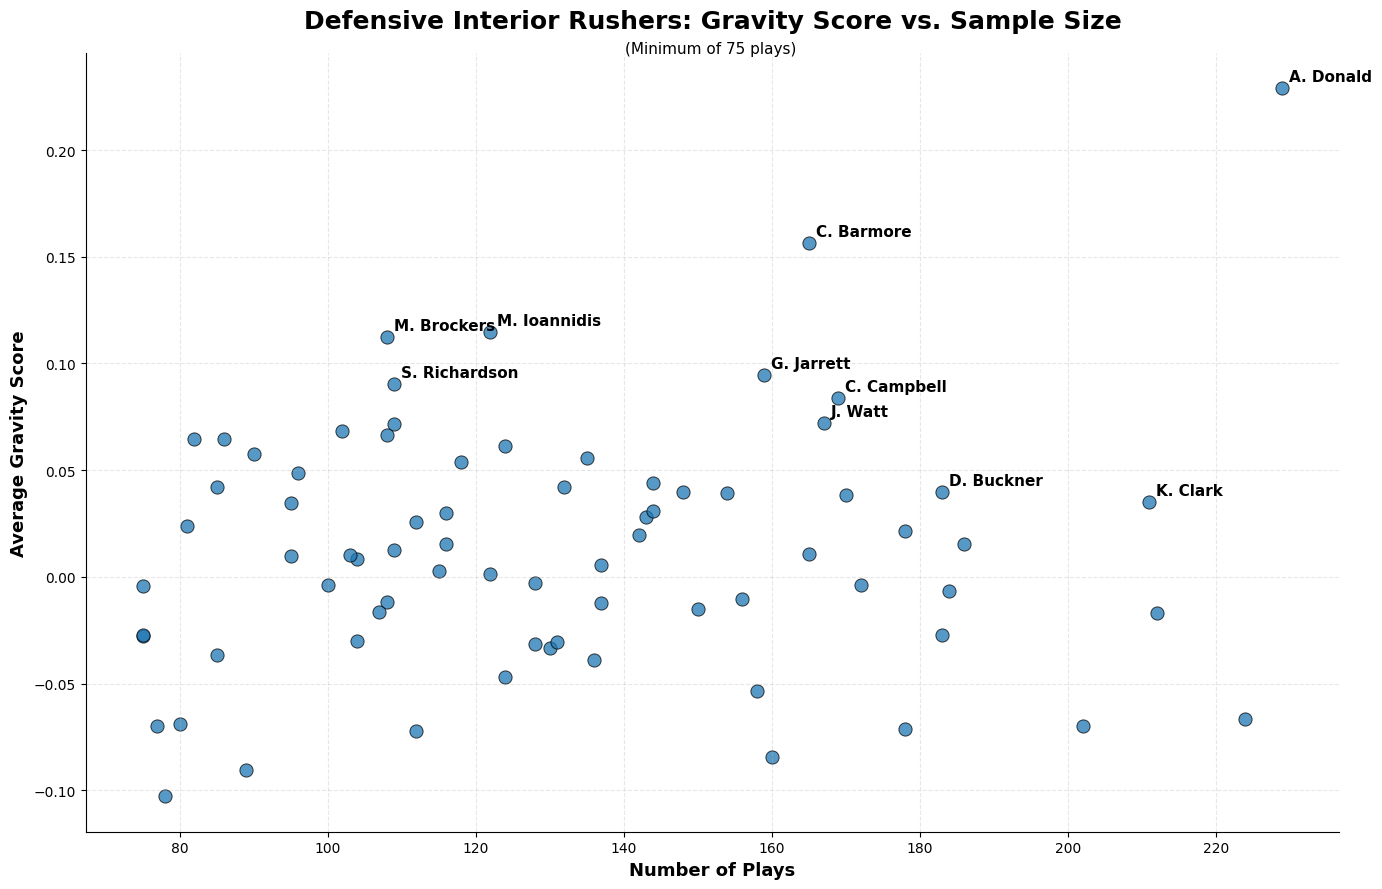

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------
# 1. Filter to DI rushers and keep needed cols
# --------------------------------------------
plot_df = (
    df_merged[df_merged["position"] == "DI"][
        ["rusher_name", "num_rows", "gravity_score"]
    ]
    .dropna(subset=["rusher_name", "num_rows", "gravity_score"])
    .copy()
)

# --------------------------------------------
# 2. Get top 8 by gravity_score
# --------------------------------------------
top_8 = (
    plot_df.sort_values("gravity_score", ascending=False)
    .head(8)
    .copy()
)

# --------------------------------------------
# 3. Create Big Data Bowl-style scatter plot
# --------------------------------------------
fig, ax = plt.subplots(figsize=(14, 9))

# Main scatter
ax.scatter(
    plot_df["num_rows"],
    plot_df["gravity_score"],
    s=90,
    alpha=0.75,
    edgecolors="black",
    linewidths=0.7,
    color="tab:blue"
)

# # Highlight top 8 with same color, just bigger
# ax.scatter(
#     top_8["num_rows"],
#     top_8["gravity_score"],
#     s=150,
#     alpha=0.75,
#     edgecolors="black",
#     linewidths=1.0,
#     color="tab:blue",
#     zorder=3
# )

# --------------------------------------------
# 4. Add labels
#    - label top 8
#    - also force labels for specific players
# --------------------------------------------
forced_labels = {
    "Kenny Clark",
    "DeForest Buckner",
}

top_8_names = set(top_8["rusher_name"])
label_names = top_8_names | forced_labels

label_df = plot_df[plot_df["rusher_name"].isin(label_names)].copy()

for _, row in label_df.iterrows():
    first_name, *rest = row["rusher_name"].split()
    abbreviated_name = f"{first_name[0]}. {' '.join(rest)}"

    ax.annotate(
        abbreviated_name,
        xy=(row["num_rows"], row["gravity_score"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

# --------------------------------------------
# 5. Styling
# --------------------------------------------
ax.set_title(
    "Defensive Interior Rushers: Gravity Score vs. Sample Size",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Number of Plays", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Gravity Score", fontsize=13, fontweight="bold")

ax.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.45,
    0.934,
    "(Minimum of 75 plays)",
    fontsize=11
)

plt.tight_layout()

output_dir = Path("../../Gravity Visualizations")
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "defensive_interior_gravity_score_vs_sample_size.png", dpi=300, bbox_inches="tight")

plt.show()

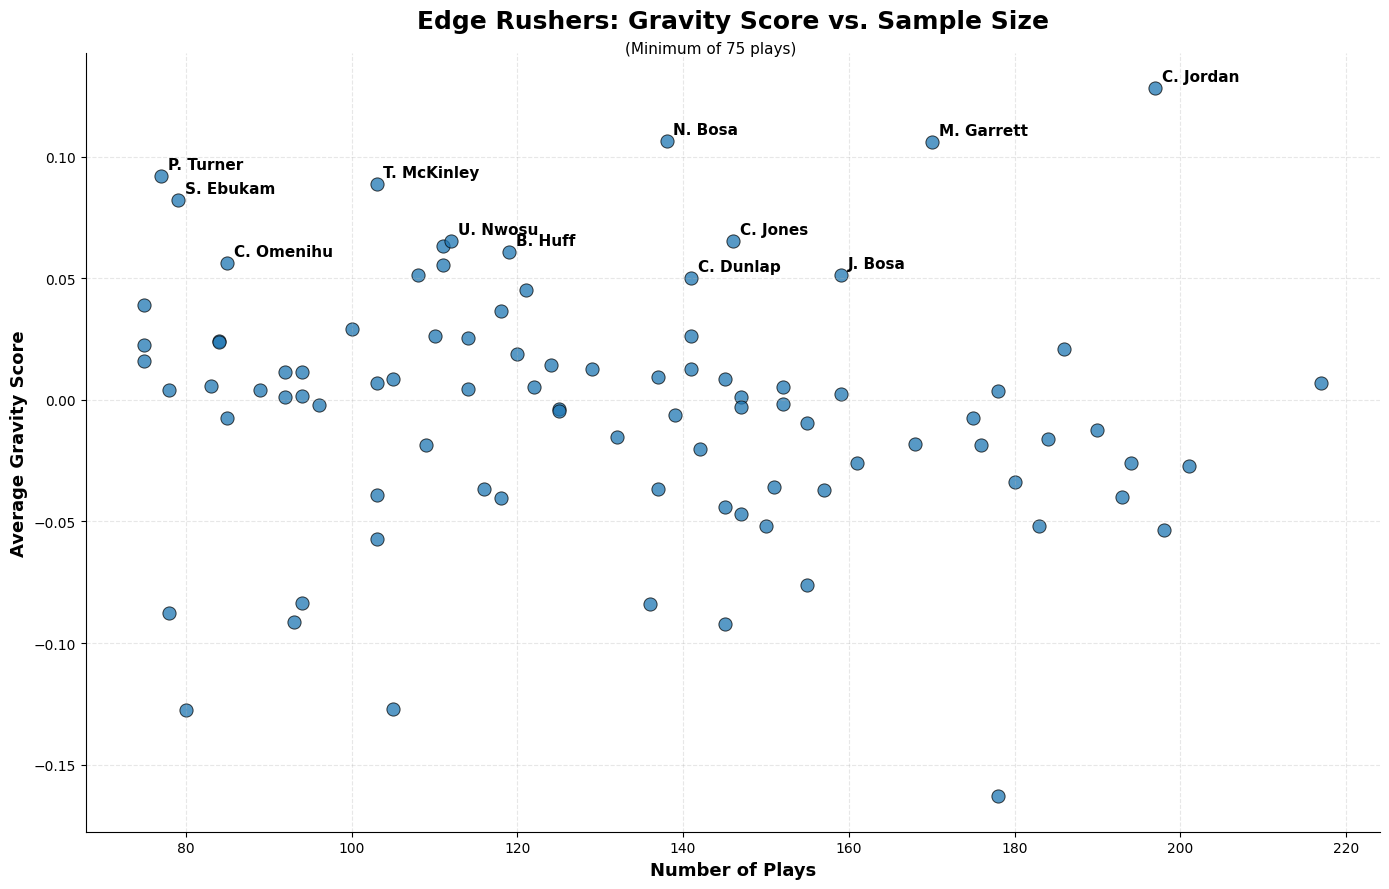

In [113]:
# edge rushers
from pathlib import Path

# --------------------------------------------
# 1. Filter to DI rushers and keep needed cols
# --------------------------------------------
plot_df = (
    df_merged[df_merged["position"] == "ED"][
        ["rusher_name", "num_rows", "gravity_score"]
    ]
    .dropna(subset=["rusher_name", "num_rows", "gravity_score"])
    .copy()
)

# --------------------------------------------
# 2. Get top 8 by gravity_score
# --------------------------------------------
top_8 = (
    plot_df.sort_values("gravity_score", ascending=False)
    .head(8)
    .copy()
)

# --------------------------------------------
# 3. Create Big Data Bowl-style scatter plot
# --------------------------------------------
fig, ax = plt.subplots(figsize=(14, 9))

# Main scatter
ax.scatter(
    plot_df["num_rows"],
    plot_df["gravity_score"],
    s=90,
    alpha=0.75,
    edgecolors="black",
    linewidths=0.7,
    color="tab:blue"
)

# # Highlight top 8 with same color, just bigger
# ax.scatter(
#     top_8["num_rows"],
#     top_8["gravity_score"],
#     s=150,
#     alpha=0.75,
#     edgecolors="black",
#     linewidths=1.0,
#     color="tab:blue",
#     zorder=3
# )

# --------------------------------------------
# 4. Add labels
#    - label top 8
#    - also force labels for specific players
# --------------------------------------------
forced_labels = {
    "Bryce Huff",
    "Charles Omenihu",
    "Joey Bosa",
    "Carlos Dunlap",
    
    
}

top_8_names = set(top_8["rusher_name"])
label_names = top_8_names | forced_labels

label_df = plot_df[plot_df["rusher_name"].isin(label_names)].copy()

for _, row in label_df.iterrows():
    first_name, *rest = row["rusher_name"].split()
    abbreviated_name = f"{first_name[0]}. {' '.join(rest)}"

    ax.annotate(
        abbreviated_name,
        xy=(row["num_rows"], row["gravity_score"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

# --------------------------------------------
# 5. Styling
# --------------------------------------------
ax.set_title(
    "Edge Rushers: Gravity Score vs. Sample Size",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Number of Plays", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Gravity Score", fontsize=13, fontweight="bold")

ax.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.45,
    0.934,
    "(Minimum of 75 plays)",
    fontsize=11
)

plt.tight_layout()

output_dir = Path("../../Gravity Visualizations")
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "edge_rushers_gravity_score_vs_sample_size.png", dpi=300, bbox_inches="tight")

plt.show()

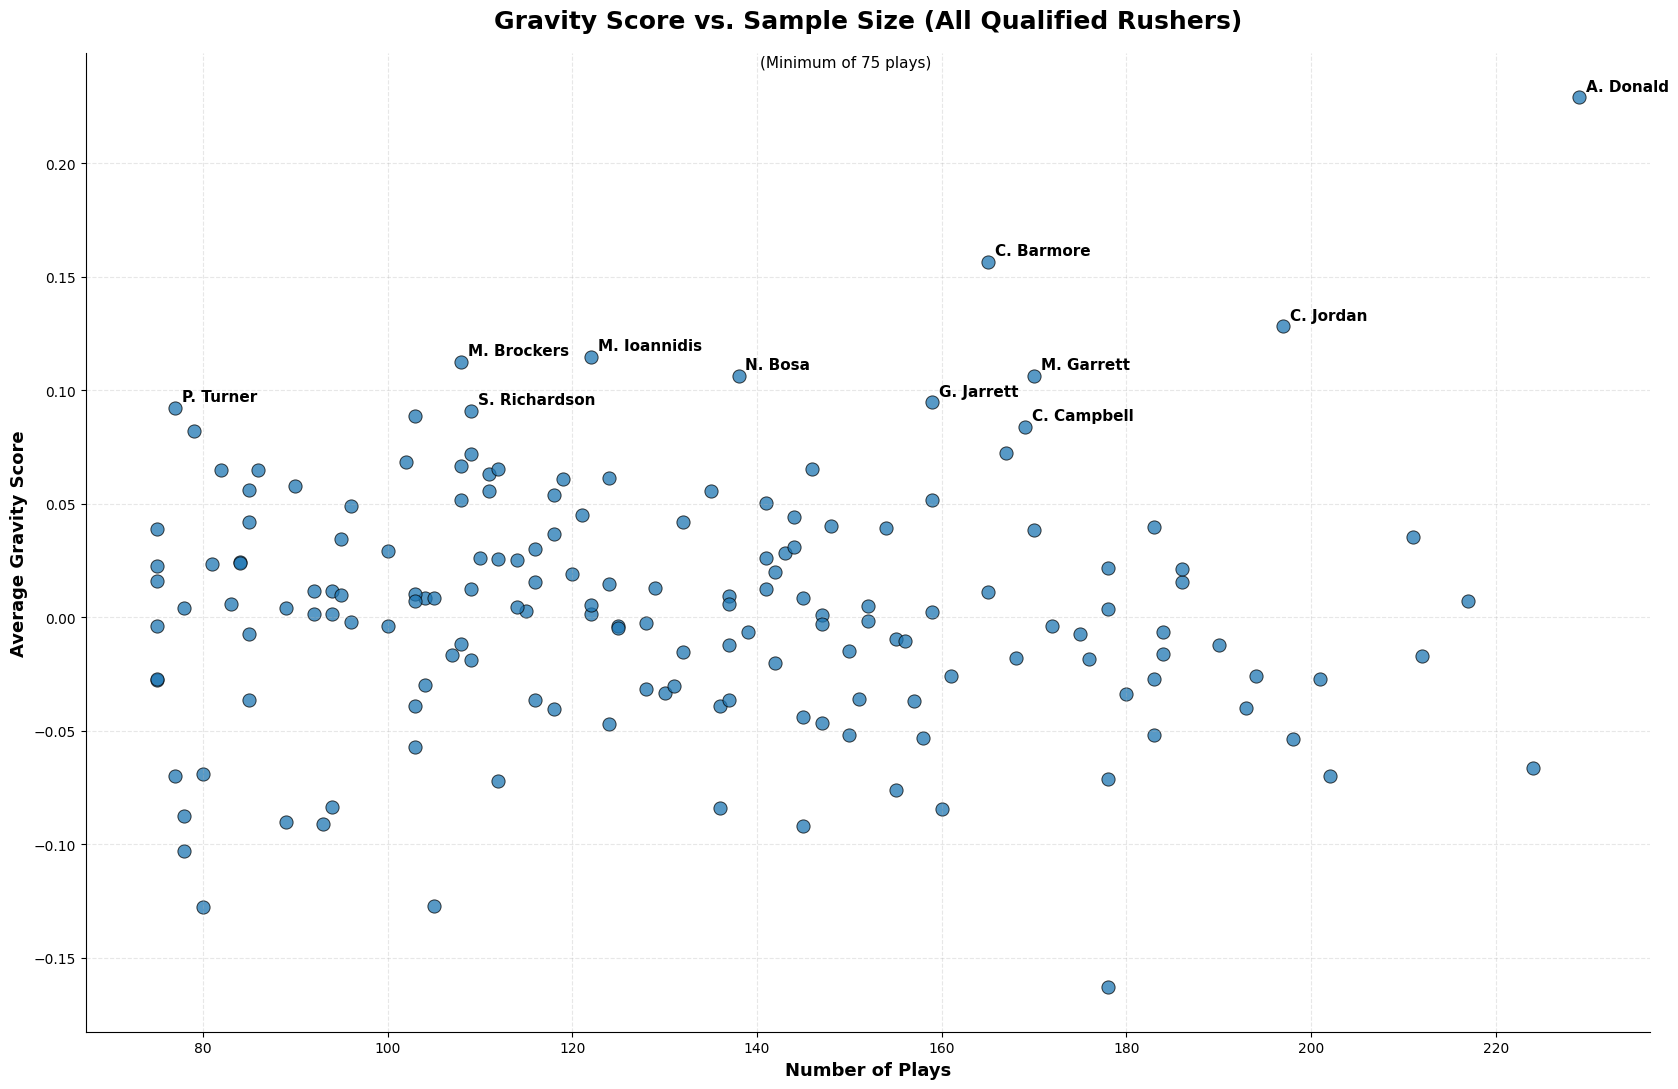

In [114]:
# all qualified rushers
from pathlib import Path

# --------------------------------------------
# 1. Filter to DI rushers and keep needed cols
# --------------------------------------------
plot_df = (
    df_merged[
        ["rusher_name", "num_rows", "gravity_score"]
    ]
    .dropna(subset=["rusher_name", "num_rows", "gravity_score"])
    .copy()
)

# --------------------------------------------
# 2. Get top 12 by gravity_score
# --------------------------------------------
top_12 = (
    plot_df.sort_values("gravity_score", ascending=False)
    .head(12)
    .copy()
)

# --------------------------------------------
# 3. Create Big Data Bowl-style scatter plot
# --------------------------------------------
fig, ax = plt.subplots(figsize=(17, 11))

# Main scatter
ax.scatter(
    plot_df["num_rows"],
    plot_df["gravity_score"],
    s=90,
    alpha=0.75,
    edgecolors="black",
    linewidths=0.7,
    color="tab:blue"
)

# # Highlight top 12 with same color, just bigger
# ax.scatter(
#     top_12["num_rows"],
#     top_12["gravity_score"],
#     s=150,
#     alpha=0.75,
#     edgecolors="black",
#     linewidths=1.0,
#     color="tab:blue",
#     zorder=3
# )

# --------------------------------------------
# 4. Add labels
#    - label top 12 EXCEPT Takkarist McKinley
#    - also force labels for specific players
# --------------------------------------------


# forced_labels = {
#     "Kenny Clark",
#     "DeForest Buckner", 
# }

top_12_names = set(top_12["rusher_name"])
excluded_names = {"Takkarist McKinley"}
label_names = (top_12_names - excluded_names)

label_df = plot_df[plot_df["rusher_name"].isin(label_names)].copy()

for _, row in label_df.iterrows():
    first_name, *rest = row["rusher_name"].split()
    abbreviated_name = f"{first_name[0]}. {' '.join(rest)}"

    ax.annotate(
        abbreviated_name,
        xy=(row["num_rows"], row["gravity_score"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

# --------------------------------------------
# 5. Styling
# --------------------------------------------
ax.set_title(
    "Gravity Score vs. Sample Size (All Qualified Rushers)",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Number of Plays", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Gravity Score", fontsize=13, fontweight="bold")

ax.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.45,
    0.934,
    "(Minimum of 75 plays)",
    fontsize=11
)

plt.tight_layout()

output_dir = Path("../../Gravity Visualizations")
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "all_qualified_rushers_gravity_score_vs_sample_size.png", dpi=300, bbox_inches="tight")

plt.show()


### Creating Pass Rush Productivity Score

In [115]:
pffScoutingData = pd.read_csv("../../datasets/pffScoutingData.csv")
pffScoutingData.columns = pffScoutingData.columns.str.strip().str.replace('"', '', regex=False)
pffScoutingData.dtypes

gameId                    int64
playId                    int64
nflId                     int64
pff_role                    str
pff_positionLinedUp         str
pff_hit                     str
pff_hurry                   str
pff_sack                    str
pff_beatenByDefender        str
pff_hitAllowed              str
pff_hurryAllowed            str
pff_sackAllowed             str
pff_nflIdBlockedPlayer      str
pff_blockType               str
pff_backFieldBlock          str
dtype: object

In [116]:
# Keep only the PFF outcome columns needed for the pass-rusher merge.
pff_pass_rush_outcomes = pffScoutingData[
    ["gameId", "playId", "nflId", "pff_hit", "pff_hurry", "pff_sack"]
].copy()

# The raw PFF file stores these 0/1 columns as padded strings and uses "NA"
# for rows where the metric is not applicable, so clean them before merging.
for col in ["pff_hit", "pff_hurry", "pff_sack"]:
    pff_pass_rush_outcomes[col] = pd.to_numeric(
        pff_pass_rush_outcomes[col].astype(str).str.strip(),
        errors="coerce",
    )

# One row in gravity_dataset is one pass rusher on one play, so this should be
# a strict one-to-one merge at the same grain.
gravity_dataset_with_pff = gravity_dataset.merge(
    pff_pass_rush_outcomes,
    on=["gameId", "playId", "nflId"],
    how="left",
    validate="one_to_one",
)

# Every row in gravity_dataset is supposed to be a pass rusher, so these outcome
# columns should be present after the merge.
outcome_cols = ["pff_hit", "pff_hurry", "pff_sack"]
if gravity_dataset_with_pff[outcome_cols].isna().any().any():
    raise ValueError("Missing PFF pass-rush outcomes after merging gravity_dataset.")

gravity_dataset_with_pff[outcome_cols] = gravity_dataset_with_pff[outcome_cols].astype(int)

# Aggregate to one row per player.
player_pass_rush_totals = (
    gravity_dataset_with_pff
    .groupby("nflId", as_index=False)
    .agg(
        rusher_name=("rusher_name", "first"),
        total_hits=("pff_hit", "sum"),
        total_hurries=("pff_hurry", "sum"),
        total_sacks=("pff_sack", "sum"),
        total_plays=("playId", "size"),
    )
    .sort_values("total_plays", ascending=False)
    .reset_index(drop=True)
)

player_pass_rush_totals


,nflId,rusher_name,total_hits,total_hurries,total_sacks,total_plays
0,41239,Aaron Donald,5,22,6,229
1,47802,Jeffery Simmons,4,24,3,224
2,52410,Chase Young,3,13,2,217
3,42349,Leonard Williams,4,13,6,212
4,43316,Kenny Clark,5,23,2,211
...,...,...,...,...,...,...
680,52797,Joe Bachie,0,0,0,1
681,53521,NaN,0,0,0,1
682,44845,Kevin King,1,0,0,1
683,52469,Kristian Fulton,0,1,0,1


In [117]:
pff_roles = pffScoutingData[["gameId", "playId", "nflId", "pff_role"]].copy()
pff_roles["pff_role"] = pff_roles["pff_role"].astype(str).str.strip().str.replace('"', '', regex=False)

gravity_dataset_with_pff = gravity_dataset_with_pff.merge(
    pff_roles,
    on=["gameId", "playId", "nflId"],
    how="left",
    validate="one_to_one",
)

if not gravity_dataset_with_pff["pff_role"].eq("Pass Rush").all():
    non_pass_rush_roles = gravity_dataset_with_pff.loc[
        ~gravity_dataset_with_pff["pff_role"].eq("Pass Rush"),
        "pff_role",
    ].value_counts(dropna=False)
    raise ValueError(
        f"Expected every merged row to be a pass rusher, found: {non_pass_rush_roles.to_dict()}"
    )

gravity_dataset_with_pff


,avg_attention_score,gameId,playId,nflId,rusher_name,officialPosition,expected_attention,gravity_score,pff_hit,pff_hurry,pff_sack,pff_role
0,0.461538,2021090900,97,41263,Demarcus Lawrence,DE,0.904706,-0.443167,0,1,0,Pass Rush
1,0.615385,2021090900,97,42403,Randy Gregory,DE,0.368581,0.246803,0,1,0,Pass Rush
2,1.307692,2021090900,97,44955,Carlos Watkins,DE,1.218276,0.089416,0,0,0,Pass Rush
3,1.000000,2021090900,97,53441,Micah Parsons,OLB,1.141261,-0.141261,0,1,0,Pass Rush
4,0.615385,2021090900,97,53504,Osa Odighizuwa,DT,1.118670,-0.503285,0,1,0,Pass Rush
...,...,...,...,...,...,...,...,...,...,...,...,...
30966,0.904762,2021110100,4411,52585,Michael Danna,DE,1.067956,-0.163194,0,0,0,Pass Rush
30967,0.923077,2021110100,4433,42406,Frank Clark,DE,0.914866,0.008211,0,0,1,Pass Rush
30968,1.500000,2021110100,4433,43326,Chris Jones,DT,1.531492,-0.031492,0,0,0,Pass Rush
30969,1.346154,2021110100,4433,43338,Jarran Reed,DT,1.384898,-0.038745,0,1,0,Pass Rush


In [118]:
old_df_merged = df_merged.copy()

In [119]:

df_merged = old_df_merged.merge(
    player_pass_rush_totals[["nflId", "total_hits", "total_hurries", "total_sacks"]],
    on="nflId",
    how="left",
    validate="one_to_one",
)

# Pass Rush Productivity: (sacks + ((hits + hurries) / 2)) * 100 / plays
df_merged["prp"] = (
    (df_merged["total_sacks"] + ((df_merged["total_hits"] + df_merged["total_hurries"]) / 2))
    * 100
    / df_merged["num_rows"]
)

prp_output_cols = [
    "nflId",
    "rusher_name",
    "position",
    "num_rows",
    "total_hits",
    "total_hurries",
    "total_sacks",
    "prp",
]

top_15_prp_di = (
    df_merged[df_merged["position"] == "DI"]
    .sort_values("prp", ascending=False)
    .head(15)[prp_output_cols]
    .reset_index(drop=True)
)

top_15_prp_ed = (
    df_merged[df_merged["position"] == "ED"]
    .sort_values("prp", ascending=False)
    .head(15)[prp_output_cols]
    .reset_index(drop=True)
)

top_20_prp_overall = (
    df_merged
    .sort_values("prp", ascending=False)
    .head(20)[prp_output_cols]
    .reset_index(drop=True)
)

display(top_15_prp_di)
display(top_15_prp_ed)
display(top_20_prp_overall)


,nflId,rusher_name,position,num_rows,total_hits,total_hurries,total_sacks,prp
0,43378,Javon Hargrave,DI,150,6,14,5,10.000000
1,44829,Jonathan Allen,DI,186,8,18,5,9.677419
2,43326,Chris Jones,DI,122,3,14,3,9.426230
3,44815,Solomon Thomas,DI,112,6,9,3,9.375000
4,41239,Aaron Donald,DI,229,5,22,6,8.515284
5,47917,Greg Gaines,DI,104,1,12,2,8.173077
6,47786,Quinnen Williams,DI,136,3,11,4,8.088235
7,53504,Osa Odighizuwa,DI,154,3,15,3,7.792208
8,42360,Arik Armstead,DI,137,1,18,1,7.664234
9,37104,Cameron Heyward,DI,184,2,20,3,7.608696


,nflId,rusher_name,position,num_rows,total_hits,total_hurries,total_sacks,prp
0,44813,Myles Garrett,ED,170,6,23,12,15.588235
1,44915,Trey Hendrickson,ED,178,5,24,9,13.202247
2,47785,Nick Bosa,ED,138,9,13,7,13.043478
3,42403,Randy Gregory,ED,129,7,16,5,12.790698
4,43435,Matt Judon,ED,161,5,20,7,12.111801
5,53441,Micah Parsons,ED,96,4,13,3,11.979167
6,47889,Maxx Crosby,ED,193,8,26,6,11.917098
7,46110,Harold Landry,ED,190,7,22,8,11.842105
8,41915,Shaquil Barrett,ED,194,4,28,6,11.340206
9,41227,Jadeveon Clowney,ED,137,3,17,5,10.948905


,nflId,rusher_name,position,num_rows,total_hits,total_hurries,total_sacks,prp
0,44813,Myles Garrett,ED,170,6,23,12,15.588235
1,44915,Trey Hendrickson,ED,178,5,24,9,13.202247
2,47785,Nick Bosa,ED,138,9,13,7,13.043478
3,42403,Randy Gregory,ED,129,7,16,5,12.790698
4,43435,Matt Judon,ED,161,5,20,7,12.111801
5,53441,Micah Parsons,ED,96,4,13,3,11.979167
6,47889,Maxx Crosby,ED,193,8,26,6,11.917098
7,46110,Harold Landry,ED,190,7,22,8,11.842105
8,41915,Shaquil Barrett,ED,194,4,28,6,11.340206
9,41227,Jadeveon Clowney,ED,137,3,17,5,10.948905


In [128]:

# Gravity-adjusted PRP gives more weight to production from rushers who drew
# above-expected attention.
df_merged["gravity_adjusted_prp"] = df_merged["prp"] * (1 + df_merged["gravity_score"])

gravity_adjusted_prp_output_cols = [
    "nflId",
    "rusher_name",
    "position",
    "num_rows",
    "total_hits",
    "total_hurries",
    "total_sacks",
    "prp",
    "gravity_score",
    "gravity_adjusted_prp",
    "team_name"
]

top_15_gravity_adjusted_prp_di = (
    df_merged[df_merged["position"] == "DI"]
    .sort_values("gravity_adjusted_prp", ascending=False)
    .head(15)[gravity_adjusted_prp_output_cols]
    .reset_index(drop=True)
)

top_15_gravity_adjusted_prp_ed = (
    df_merged[df_merged["position"] == "ED"]
    .sort_values("gravity_adjusted_prp", ascending=False)
    .head(15)[gravity_adjusted_prp_output_cols]
    .reset_index(drop=True)
)

top_20_gravity_adjusted_prp_overall = (
    df_merged
    .sort_values("gravity_adjusted_prp", ascending=False)
    .head(20)[gravity_adjusted_prp_output_cols]
    .reset_index(drop=True)
)

display(top_15_gravity_adjusted_prp_di)
display(top_15_gravity_adjusted_prp_ed)
display(top_20_gravity_adjusted_prp_overall)


,nflId,rusher_name,position,num_rows,total_hits,total_hurries,total_sacks,prp,gravity_score,gravity_adjusted_prp,team_name
0,41239,Aaron Donald,DI,229,5,22,6,8.515284,0.228889,10.464337,LA
1,43378,Javon Hargrave,DI,150,6,14,5,10.000000,-0.014846,9.851540,PHI
2,44829,Jonathan Allen,DI,186,8,18,5,9.677419,0.015365,9.826116,WAS
3,44815,Solomon Thomas,DI,112,6,9,3,9.375000,0.025737,9.616285,LV
4,43326,Chris Jones,DI,122,3,14,3,9.426230,0.001277,9.438268,KC
5,53504,Osa Odighizuwa,DI,154,3,15,3,7.792208,0.039188,8.097567,DAL
6,47917,Greg Gaines,DI,104,1,12,2,8.173077,-0.029887,7.928810,LA
7,43316,Kenny Clark,DI,211,5,23,2,7.582938,0.035074,7.848899,GB
8,39960,Star Lotulelei,DI,82,1,7,2,7.317073,0.064669,7.790261,BUF
9,47786,Quinnen Williams,DI,136,3,11,4,8.088235,-0.038966,7.773069,NYJ


,nflId,rusher_name,position,num_rows,total_hits,total_hurries,total_sacks,prp,gravity_score,gravity_adjusted_prp,team_name
0,44813,Myles Garrett,ED,170,6,23,12,15.588235,0.106137,17.242725,CLV
1,47785,Nick Bosa,ED,138,9,13,7,13.043478,0.106330,14.430388,SF
2,44915,Trey Hendrickson,ED,178,5,24,9,13.202247,0.003497,13.248416,CIN
3,42403,Randy Gregory,ED,129,7,16,5,12.790698,0.012870,12.955318,DAL
4,53441,Micah Parsons,ED,96,4,13,3,11.979167,-0.002182,11.953032,DAL
5,43435,Matt Judon,ED,161,5,20,7,12.111801,-0.025961,11.797368,NE
6,46110,Harold Landry,ED,190,7,22,8,11.842105,-0.012422,11.694997,TEN
7,47889,Maxx Crosby,ED,193,8,26,6,11.917098,-0.040134,11.438817,LV
8,41227,Jadeveon Clowney,ED,137,3,17,5,10.948905,0.009214,11.049785,CLV
9,41915,Shaquil Barrett,ED,194,4,28,6,11.340206,-0.025813,11.047487,TB


,nflId,rusher_name,position,num_rows,total_hits,total_hurries,total_sacks,prp,gravity_score,gravity_adjusted_prp,team_name
0,44813,Myles Garrett,ED,170,6,23,12,15.588235,0.106137,17.242725,CLV
1,47785,Nick Bosa,ED,138,9,13,7,13.043478,0.106330,14.430388,SF
2,44915,Trey Hendrickson,ED,178,5,24,9,13.202247,0.003497,13.248416,CIN
3,42403,Randy Gregory,ED,129,7,16,5,12.790698,0.012870,12.955318,DAL
4,53441,Micah Parsons,ED,96,4,13,3,11.979167,-0.002182,11.953032,DAL
5,43435,Matt Judon,ED,161,5,20,7,12.111801,-0.025961,11.797368,NE
6,46110,Harold Landry,ED,190,7,22,8,11.842105,-0.012422,11.694997,TEN
7,47889,Maxx Crosby,ED,193,8,26,6,11.917098,-0.040134,11.438817,LV
8,41227,Jadeveon Clowney,ED,137,3,17,5,10.948905,0.009214,11.049785,CLV
9,41915,Shaquil Barrett,ED,194,4,28,6,11.340206,-0.025813,11.047487,TB


In [121]:
# # Actual-attention-adjusted PRP scales production by the player's observed
# # average attention level.
# df_merged["actual_attention_adjusted_prp"] = df_merged["prp"] * df_merged["actual_attention"]

# actual_attention_adjusted_prp_output_cols = [
#     "nflId",
#     "rusher_name",
#     "position",
#     "num_rows",
#     "total_hits",
#     "total_hurries",
#     "total_sacks",
#     "prp",
#     "actual_attention",
#     "actual_attention_adjusted_prp",
# ]

# top_15_actual_attention_adjusted_prp_di = (
#     df_merged[df_merged["position"] == "DI"]
#     .sort_values("actual_attention_adjusted_prp", ascending=False)
#     .head(15)[actual_attention_adjusted_prp_output_cols]
#     .reset_index(drop=True)
# )

# top_15_actual_attention_adjusted_prp_ed = (
#     df_merged[df_merged["position"] == "ED"]
#     .sort_values("actual_attention_adjusted_prp", ascending=False)
#     .head(15)[actual_attention_adjusted_prp_output_cols]
#     .reset_index(drop=True)
# )

# top_20_actual_attention_adjusted_prp_overall = (
#     df_merged
#     .sort_values("actual_attention_adjusted_prp", ascending=False)
#     .head(20)[actual_attention_adjusted_prp_output_cols]
#     .reset_index(drop=True)
# )

# display(top_15_actual_attention_adjusted_prp_di)
# display(top_15_actual_attention_adjusted_prp_ed)
# display(top_20_actual_attention_adjusted_prp_overall)


\
   nflId        rusher_name position num_rows gravity_score        prp   
0  41239       Aaron Donald       DI      229      0.228889   8.515284   
1  53467  Christian Barmore       DI      165      0.156271   5.757576   
2  44815     Solomon Thomas       DI      112      0.025737   9.375000   
3  44829     Jonathan Allen       DI      186      0.015365   9.677419   
4  37084          J.J. Watt       DI      167      0.072197   7.185629   
5  43378     Javon Hargrave       DI      150     -0.014846  10.000000   
6  39960     Star Lotulelei       DI       82      0.064669   7.317073   
7  43326        Chris Jones       DI      122      0.001277   9.426230   
8  43441     Matt Ioannidis       DI      122      0.114744   5.327869   
9  53504     Osa Odighizuwa       DI      154      0.039188   7.792208   

  standardized values                                        
      gravity_z_score prp_z_score average_z_score team_name  
0            3.729969    1.593124        2.661547        LA  
1            2.472754    0.163834        1.318294        NE  
2            0.212831    2.038706        1.125768        LV  
3            0.033265    2.195446        1.114356       WAS  
4            1.017186    0.903979        0.960582       ARZ  
5           -0.489780    2.362636        0.936428       PHI  
6            0.886854    0.972105        0.929479       BUF  
7           -0.210641    2.065257        0.927308        KC  
8            1.753797   -0.058878        0.847460       WAS  
9            0.445701    1.218362        0.832031       DAL

\
   nflId        rusher_name position num_rows gravity_score       prp   
0  48544         Shy Tuttle       DI       78     -0.102833  0.641026   
1  44991     Davon Godchaux       DI       89     -0.090448  2.808989   
2  52665      Malcolm Roach       DI       77     -0.069830  2.597403   
3  53624          Roy Lopez       DI       75     -0.027181  2.000000   
4  40171  Nicholas Williams       DI      112     -0.072213  3.571429   
5  46264   Sebastian Joseph       DI      160     -0.084432  4.687500   
6  40042   Brandon Williams       DI       80     -0.068902  4.375000   
7  39997  Johnathan Hankins       DI      104      0.008231  1.923077   
8  44877     Larry Ogunjobi       DI      178     -0.071317  5.617978   
9  45226         Josh Tupou       DI       85     -0.036435  4.705882   

  standardized values                                        
      gravity_z_score prp_z_score average_z_score team_name  
0           -2.013084   -2.488017       -2.250551        NO  
1           -1.798669   -1.364386       -1.581528        NE  
2           -1.441707   -1.474049       -1.457878        NO  
3           -0.703340   -1.783676       -1.243508       HST  
4           -1.482960   -0.969222       -1.226091       DET  
5           -1.694512   -0.390774       -1.042643        LA  
6           -1.425640   -0.552739       -0.989190       BLT  
7           -0.090256   -1.823544       -0.956900        LV  
8           -1.467447    0.091482       -0.687982       CIN  
9           -0.863540   -0.381247       -0.622393       CIN

\
   nflId         rusher_name position num_rows gravity_score        prp   
0  44813       Myles Garrett       ED      170      0.106137  15.588235   
1  47785           Nick Bosa       ED      138      0.106330  13.043478   
2  37097      Cameron Jordan       ED      197      0.128034   6.852792   
3  42403       Randy Gregory       ED      129      0.012870  12.790698   
4  44915    Trey Hendrickson       ED      178      0.003497  13.202247   
5  43292           Joey Bosa       ED      159      0.051487   9.748428   
6  44838  Takkarist McKinley       ED      103      0.088801   7.281553   
7  53441       Micah Parsons       ED       96     -0.002182  11.979167   
8  44842           T.J. Watt       ED      141      0.026149  10.283688   
9  41227    Jadeveon Clowney       ED      137      0.009214  10.948905   

  standardized values                                        
      gravity_z_score prp_z_score average_z_score team_name  
0            2.097082    2.982936        2.540009       CLV  
1            2.100825    2.046263        2.073544        SF  
2            2.522513   -0.232403        1.145055        NO  
3            0.284988    1.953220        1.119104       DAL  
4            0.102872    2.104702        1.103787       CIN  
5            1.035278    0.833422        0.934350       LAC  
6            1.760250   -0.074584        0.842833       CLV  
7           -0.007461    1.654511        0.823525       DAL  
8            0.542984    1.030440        0.786712       PIT  
9            0.213942    1.275293        0.744618       CLV

\
   nflId         rusher_name position num_rows gravity_score       prp   
0  53450          Kwity Paye       ED       93     -0.091170  3.225806   
1  42031        Denico Autry       ED      178     -0.163026  8.988764   
2  45009  Al-Quadin Muhammad       ED      145     -0.092134  5.862069   
3  41786         Kerry Hyder       ED      155     -0.076050  5.161290   
4  44863     DeMarcus Walker       ED       80     -0.127518  8.125000   
5  46135      Lorenzo Carter       ED      116     -0.036480  3.448276   
6  52525         D.J. Wonnum       ED      142     -0.020363  2.816901   
7  44944       Deatrich Wise       ED      109     -0.018742  2.752294   
8  40051         Alex Okafor       ED      103     -0.057185  4.854369   
9  48089          Malik Reed       ED      183     -0.051773  5.737705   

  standardized values                                        
      gravity_z_score prp_z_score average_z_score team_name  
0           -1.736435   -1.567422       -1.651928       IND  
1           -3.132534    0.553805       -1.289364       TEN  
2           -1.755152   -0.597068       -1.176110       IND  
3           -1.442656   -0.855010       -1.148833       SEA  
4           -2.442641    0.235871       -1.103385       HST  
5           -0.673847   -1.485536       -1.079691       NYG  
6           -0.360702   -1.717932       -1.039317       MIN  
7           -0.329212   -1.741713       -1.035462        NE  
8           -1.076123   -0.967981       -1.022052        KC  
9           -0.970976   -0.642843       -0.806910       DEN

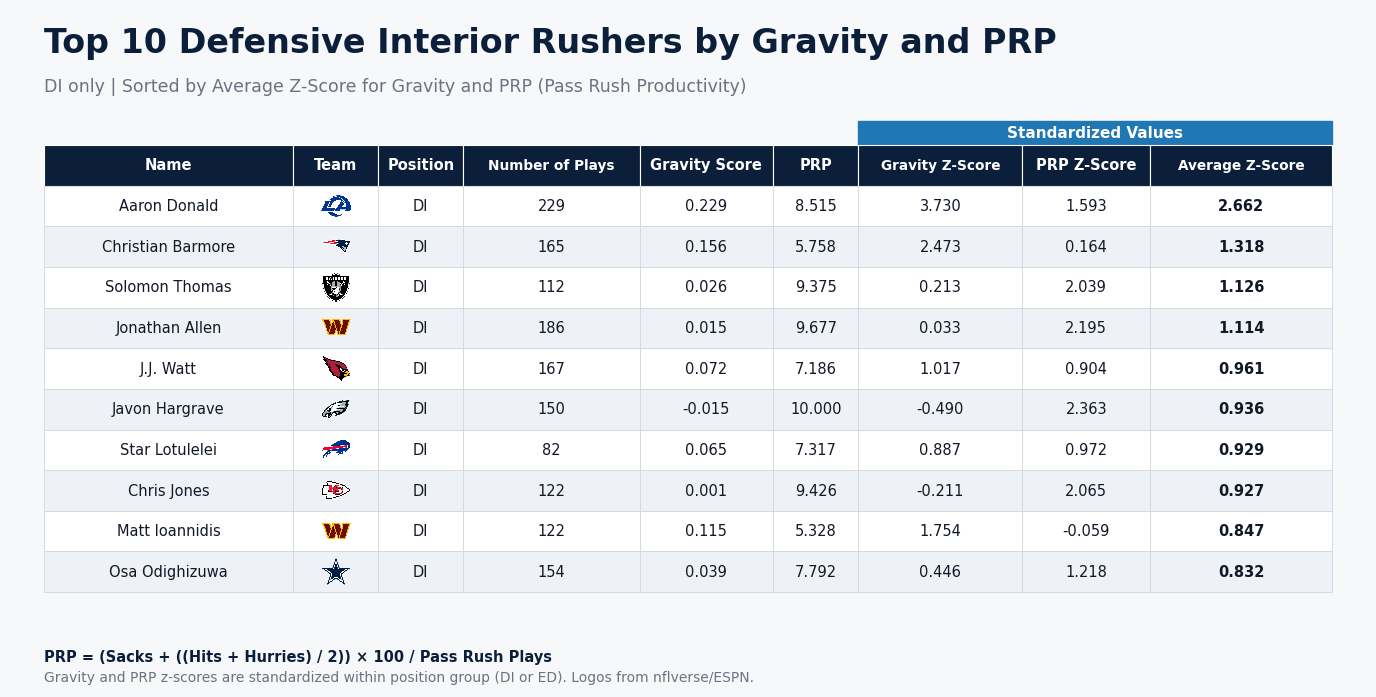

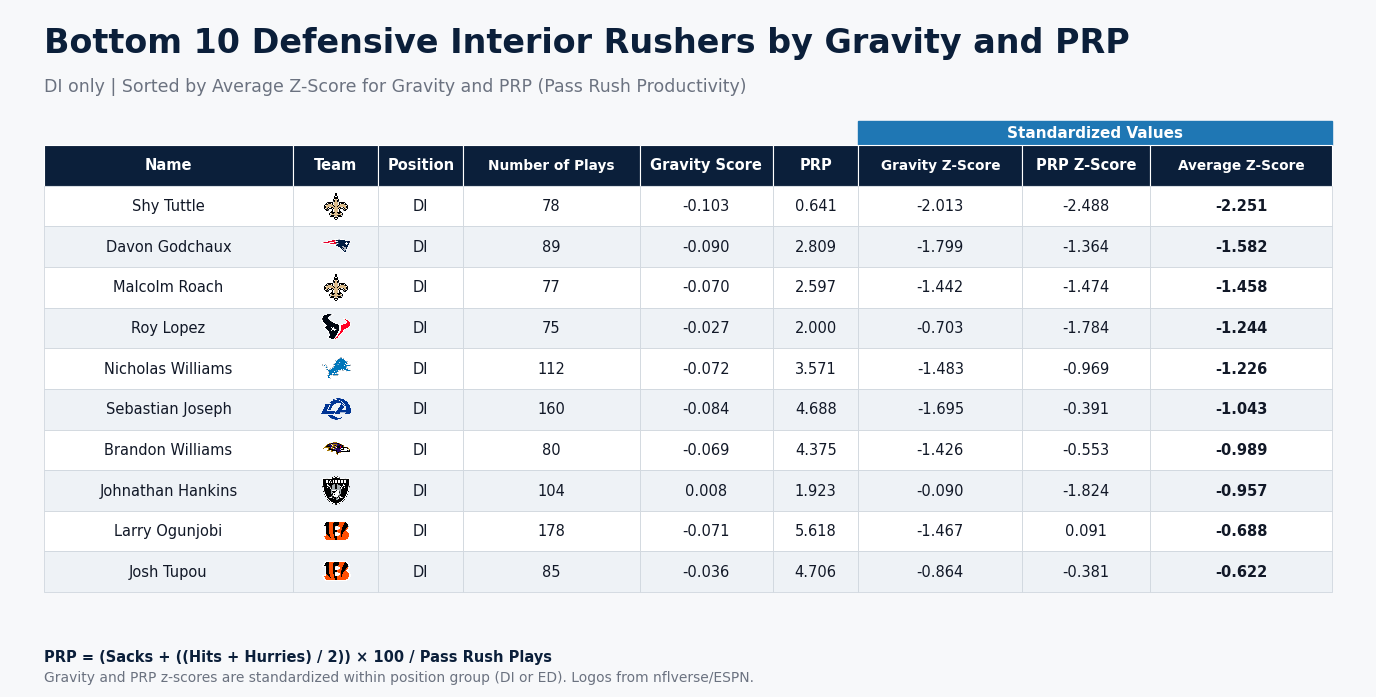

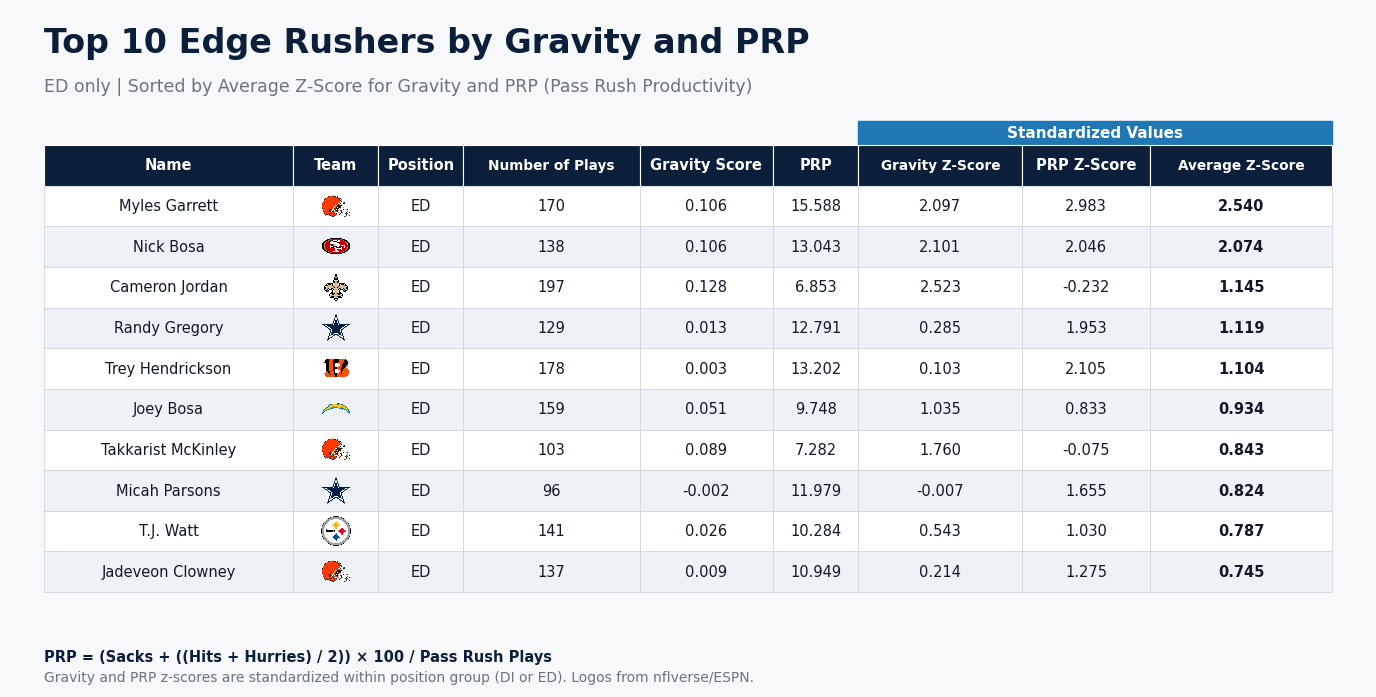

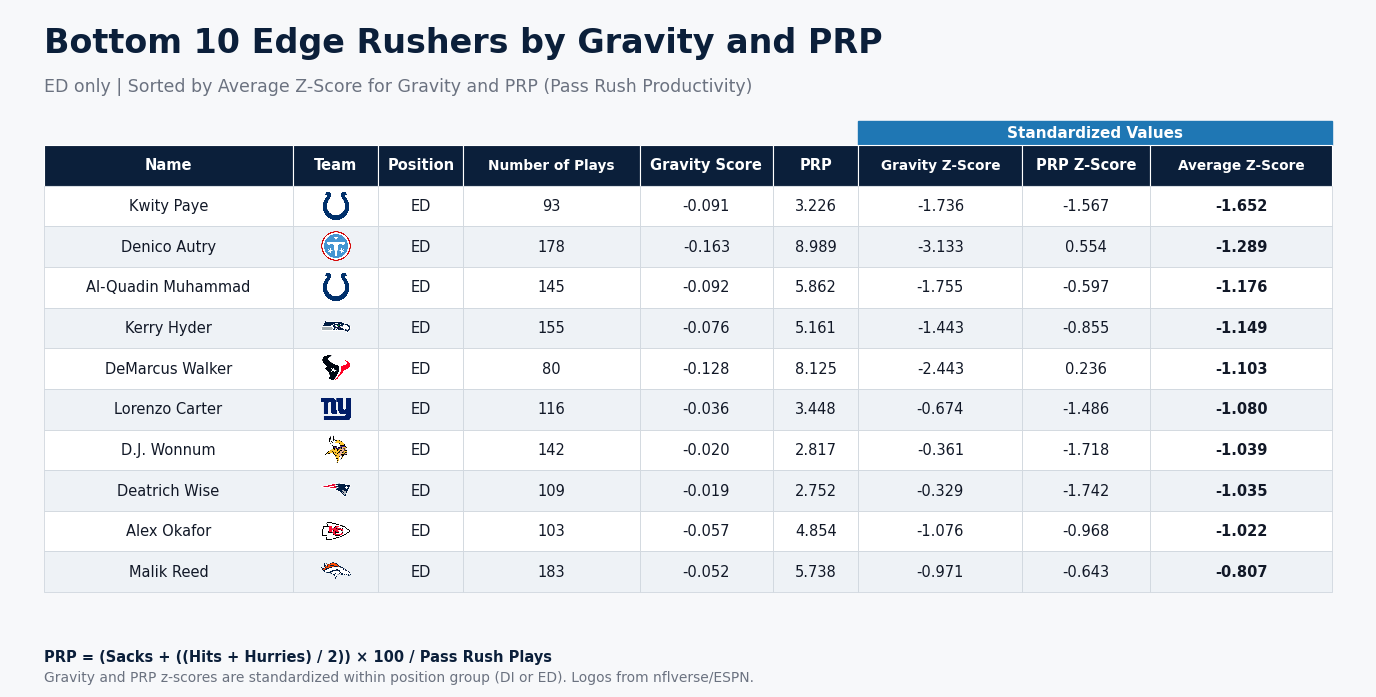

In [135]:
# codex here


# calculate z-scores for DI and ED separately
df_merged_di = df_merged[df_merged["position"] == "DI"].copy()
df_merged_ed = df_merged[df_merged["position"] == "ED"].copy()

for position_df in [df_merged_di, df_merged_ed]:
    position_df["gravity_z_score"] = (
        (position_df["gravity_score"] - position_df["gravity_score"].mean())
        / position_df["gravity_score"].std()
    )
    position_df["prp_z_score"] = (
        (position_df["prp"] - position_df["prp"].mean())
        / position_df["prp"].std()
    )
    position_df["average_z_score"] = (
        position_df[["gravity_z_score", "prp_z_score"]].mean(axis=1)
    )

z_score_output_cols = [
    "nflId",
    "rusher_name",
    "position",
    "num_rows",
    "gravity_score",
    "prp",
    "gravity_z_score",
    "prp_z_score",
    "average_z_score",
    "team_name"
]

top_10_average_z_score_di = (
    df_merged_di
    .sort_values("average_z_score", ascending=False)
    .head(10)[z_score_output_cols]
    .reset_index(drop=True)
)

bottom_10_average_z_score_di = (
    df_merged_di
    .sort_values("average_z_score", ascending=True)
    .head(10)[z_score_output_cols]
    .reset_index(drop=True)
)

top_10_average_z_score_ed = (
    df_merged_ed
    .sort_values("average_z_score", ascending=False)
    .head(10)[z_score_output_cols]
    .reset_index(drop=True)
)

bottom_10_average_z_score_ed = (
    df_merged_ed
    .sort_values("average_z_score", ascending=True)
    .head(10)[z_score_output_cols]
    .reset_index(drop=True)
)

standardized_value_cols = ["gravity_z_score", "prp_z_score", "average_z_score"]


def add_standardized_values_header(df):
    display_df = df.copy()
    display_df.columns = pd.MultiIndex.from_tuples(
        [
            ("standardized values", col) if col in standardized_value_cols else ("", col)
            for col in display_df.columns
        ]
    )
    return display_df


display(add_standardized_values_header(top_10_average_z_score_di))
display(add_standardized_values_header(bottom_10_average_z_score_di))
display(add_standardized_values_header(top_10_average_z_score_ed))
display(add_standardized_values_header(bottom_10_average_z_score_ed))


# codex here



# Big Data Bowl-style Top/Bottom 10 tables with team logos.
# Logo source: nflverse teams_colors_logos.csv, using ESPN logo URLs.
import io
import urllib.request
from pathlib import Path

import matplotlib.image as mpimg
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib.patches import Rectangle

NFLVERSE_TEAM_LOGOS_URL = (
    "https://raw.githubusercontent.com/nflverse/nflverse-pbp/master/teams_colors_logos.csv"
)

# PFF abbreviations differ from nflverse for a few teams. This mapping keeps
# team_name values aligned to the correct NFL logo.
pff_to_nflverse_team_abbr = {
    "ARZ": "ARI",
    "BLT": "BAL",
    "CLV": "CLE",
    "HST": "HOU",
    "LA": "LAR",
}

team_logo_metadata = pd.read_csv(NFLVERSE_TEAM_LOGOS_URL)
team_logo_metadata["team_abbr"] = team_logo_metadata["team_abbr"].astype(str).str.upper()
logo_url_by_team = team_logo_metadata.set_index("team_abbr")["team_logo_espn"].to_dict()

logo_cache_dir = Path("../../Gravity Visualizations/team_logos")
logo_cache_dir.mkdir(parents=True, exist_ok=True)


def normalize_team_abbr(team_name):
    team_abbr = str(team_name).strip().upper()
    return pff_to_nflverse_team_abbr.get(team_abbr, team_abbr)


def get_logo_image(team_abbr):
    if team_abbr not in logo_url_by_team or pd.isna(logo_url_by_team[team_abbr]):
        raise ValueError(f"No logo URL found for team abbreviation: {team_abbr}")

    logo_path = logo_cache_dir / f"{team_abbr}.png"
    if not logo_path.exists():
        with urllib.request.urlopen(logo_url_by_team[team_abbr]) as response:
            logo_path.write_bytes(response.read())

    return mpimg.imread(logo_path)


def prepare_z_score_table_data(df):
    table_df = df.copy()
    table_df["team_abbr"] = table_df["team_name"].apply(normalize_team_abbr)

    missing_logo_teams = sorted(set(table_df["team_abbr"]) - set(logo_url_by_team))
    if missing_logo_teams:
        raise ValueError(f"Missing logo mapping for teams: {missing_logo_teams}")

    table_df = table_df.rename(
        columns={
            "rusher_name": "Name",
            "team_abbr": "Team",
            "position": "Position",
            "num_rows": "Number of Plays",
            "gravity_score": "Gravity Score",
            "prp": "PRP",
            "gravity_z_score": "Gravity Z-Score",
            "prp_z_score": "PRP Z-Score",
            "average_z_score": "Average Z-Score",
        }
    )

    table_df = table_df[
        [
            "Name",
            "Team",
            "Position",
            "Number of Plays",
            "Gravity Score",
            "PRP",
            "Gravity Z-Score",
            "PRP Z-Score",
            "Average Z-Score",
        ]
    ].copy()

    numeric_cols = [
        "Gravity Score",
        "PRP",
        "Gravity Z-Score",
        "PRP Z-Score",
        "Average Z-Score",
    ]
    table_df[numeric_cols] = table_df[numeric_cols].round(3)
    table_df["Number of Plays"] = table_df["Number of Plays"].astype(int)

    return table_df


def draw_big_data_bowl_z_score_table(df, title, subtitle, output_path):
    table_df = prepare_z_score_table_data(df)

    columns = list(table_df.columns)
    # Give the longer headers enough horizontal room so labels do not touch borders.
    col_widths = {
        "Name": 0.205,
        "Team": 0.070,
        "Position": 0.070,
        "Number of Plays": 0.145,
        "Gravity Score": 0.110,
        "PRP": 0.070,
        "Gravity Z-Score": 0.135,
        "PRP Z-Score": 0.105,
        "Average Z-Score": 0.150,
    }
    total_width = sum(col_widths.values())
    col_widths = {col: width / total_width for col, width in col_widths.items()}

    left_margin = 0.025
    table_width = 0.95
    x_edges = [left_margin]
    for col in columns:
        x_edges.append(x_edges[-1] + table_width * col_widths[col])

    fig, ax = plt.subplots(figsize=(17.5, 8.8))
    fig.patch.set_facecolor("#F7F8FA")
    ax.set_facecolor("#F7F8FA")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    navy = "#0B1F3A"
    blue = "#1F77B4"
    light_blue = "#DDEAF7"
    row_alt = "#EEF2F6"
    grid = "#D0D7DE"
    text = "#111827"
    muted = "#6B7280"

    ax.text(
        left_margin,
        0.975,
        title,
        ha="left",
        va="top",
        fontsize=24,
        fontweight="bold",
        color=navy,
    )
    ax.text(
        left_margin,
        0.900,
        subtitle,
        ha="left",
        va="top",
        fontsize=12.5,
        color=muted,
    )

    group_header_top = 0.835
    group_header_h = 0.035
    header_h = 0.06
    row_h = 0.06
    header_top = group_header_top - group_header_h
    first_row_top = header_top - header_h

    # Group header spanning the standardized z-score columns.
    z_start = columns.index("Gravity Z-Score")
    z_end = columns.index("Average Z-Score") + 1
    ax.add_patch(
        Rectangle(
            (x_edges[z_start], header_top),
            x_edges[z_end] - x_edges[z_start],
            group_header_h,
            facecolor=blue,
            edgecolor=blue,
            linewidth=1,
        )
    )
    ax.text(
        (x_edges[z_start] + x_edges[z_end]) / 2,
        header_top + group_header_h / 2,
        "Standardized Values",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white",
    )

    for j, col in enumerate(columns):
        x0 = x_edges[j]
        width = x_edges[j + 1] - x0
        ax.add_patch(
            Rectangle(
                (x0, first_row_top),
                width,
                header_h,
                facecolor=navy,
                edgecolor="white",
                linewidth=0.8,
            )
        )
        ax.text(
            x0 + width / 2,
            first_row_top + header_h / 2,
            col,
            ha="center",
            va="center",
            fontsize=9.8 if col in ["Number of Plays", "Gravity Z-Score", "Average Z-Score"] else 10.5,
            fontweight="bold",
            color="white",
        )

    for i, row in table_df.iterrows():
        y0 = first_row_top - ((i + 1) * row_h)
        facecolor = "white" if i % 2 == 0 else row_alt
        for j, col in enumerate(columns):
            x0 = x_edges[j]
            width = x_edges[j + 1] - x0
            ax.add_patch(
                Rectangle(
                    (x0, y0),
                    width,
                    row_h,
                    facecolor=facecolor,
                    edgecolor=grid,
                    linewidth=0.6,
                )
            )

            if col == "Team":
                logo = get_logo_image(row[col])
                imagebox = OffsetImage(logo, zoom=0.045)
                ab = AnnotationBbox(
                    imagebox,
                    (x0 + width / 2, y0 + row_h / 2),
                    frameon=False,
                    box_alignment=(0.5, 0.5),
                )
                ax.add_artist(ab)
            else:
                value = row[col]
                if col in [
                    "Gravity Score",
                    "PRP",
                    "Gravity Z-Score",
                    "PRP Z-Score",
                    "Average Z-Score",
                ]:
                    value = f"{value:.3f}"
                elif col == "Number of Plays":
                    value = f"{value:,}"

                ha = "center"
                x_text = x0 + width / 2
                ax.text(
                    x_text,
                    y0 + row_h / 2,
                    value,
                    ha=ha,
                    va="center",
                    fontsize=10.5,
                    color=text,
                    fontweight="bold" if col == "Average Z-Score" else "normal",
                )

    footer_y = first_row_top - ((len(table_df) + 1) * row_h) - 0.025
    ax.text(
        left_margin,
        footer_y,
        "PRP = (Sacks + ((Hits + Hurries) / 2)) × 100 / Pass Rush Plays",
        ha="left",
        va="top",
        fontsize=10.5,
        fontweight="bold",
        color=navy,
    )
    ax.text(
        left_margin,
        footer_y - 0.030,
        "Gravity and PRP z-scores are standardized within position group (DI or ED). Logos from nflverse/ESPN.",
        ha="left",
        va="top",
        fontsize=10,
        color=muted,
    )

    fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    display(fig)
    plt.close(fig)


output_dir = Path("../../Gravity Visualizations")
output_dir.mkdir(parents=True, exist_ok=True)

# Render position-specific Big Data Bowl-style tables. These use the existing
# DI-only and ED-only rankings above, so each table is sorted by Average Z-Score
# within its own position group.
draw_big_data_bowl_z_score_table(
    top_10_average_z_score_di,
    title="Top 10 Defensive Interior Rushers by Gravity and PRP",
    subtitle="DI only | Sorted by Average Z-Score for Gravity and PRP (Pass Rush Productivity)",
    output_path=output_dir / "top_10_di_average_z_score_table.png",
)

draw_big_data_bowl_z_score_table(
    bottom_10_average_z_score_di,
    title="Bottom 10 Defensive Interior Rushers by Gravity and PRP",
    subtitle="DI only | Sorted by Average Z-Score for Gravity and PRP (Pass Rush Productivity)",
    output_path=output_dir / "bottom_10_di_average_z_score_table.png",
)

draw_big_data_bowl_z_score_table(
    top_10_average_z_score_ed,
    title="Top 10 Edge Rushers by Gravity and PRP",
    subtitle="ED only | Sorted by Average Z-Score for Gravity and PRP (Pass Rush Productivity)",
    output_path=output_dir / "top_10_ed_average_z_score_table.png",
)

draw_big_data_bowl_z_score_table(
    bottom_10_average_z_score_ed,
    title="Bottom 10 Edge Rushers by Gravity and PRP",
    subtitle="ED only | Sorted by Average Z-Score for Gravity and PRP (Pass Rush Productivity)",
    output_path=output_dir / "bottom_10_ed_average_z_score_table.png",
)


In [ ]:


# Use the already-computed within-position z-scores so the gravity-vs-PRP
# gap is measured on a comparable scale.
for position_df in [df_merged_di, df_merged_ed]:
    position_df["gravity_prp_z_gap"] = (
        position_df["gravity_z_score"] - position_df["prp_z_score"]
    ).abs()

gravity_prp_gap_output_cols = [
    "nflId",
    "rusher_name",
    "position",
    "num_rows",
    "gravity_score",
    "prp",
    "gravity_z_score",
    "prp_z_score",
    "gravity_prp_z_gap",
]

# High gravity, low productivity: above-average gravity and below-average PRP.
high_gravity_low_productivity_di = (
    df_merged_di[
        (df_merged_di["gravity_score"] > df_merged_di["gravity_score"].mean())
        & (df_merged_di["prp"] < df_merged_di["prp"].mean())
    ]
    .sort_values("gravity_prp_z_gap", ascending=False)
    [gravity_prp_gap_output_cols]
    .reset_index(drop=True)
)

high_gravity_low_productivity_ed = (
    df_merged_ed[
        (df_merged_ed["gravity_score"] > df_merged_ed["gravity_score"].mean())
        & (df_merged_ed["prp"] < df_merged_ed["prp"].mean())
    ]
    .sort_values("gravity_prp_z_gap", ascending=False)
    [gravity_prp_gap_output_cols]
    .reset_index(drop=True)
)

# Low gravity, high productivity: below-average gravity and above-average PRP.
low_gravity_high_productivity_di = (
    df_merged_di[
        (df_merged_di["gravity_score"] < df_merged_di["gravity_score"].mean())
        & (df_merged_di["prp"] > df_merged_di["prp"].mean())
    ]
    .sort_values("gravity_prp_z_gap", ascending=False)
    [gravity_prp_gap_output_cols]
    .reset_index(drop=True)
)

low_gravity_high_productivity_ed = (
    df_merged_ed[
        (df_merged_ed["gravity_score"] < df_merged_ed["gravity_score"].mean())
        & (df_merged_ed["prp"] > df_merged_ed["prp"].mean())
    ]
    .sort_values("gravity_prp_z_gap", ascending=False)
    [gravity_prp_gap_output_cols]
    .reset_index(drop=True)
)

display(high_gravity_low_productivity_di)
display(high_gravity_low_productivity_ed)
display(low_gravity_high_productivity_di)
display(low_gravity_high_productivity_ed)


,nflId,rusher_name,position,num_rows,gravity_score,prp,gravity_z_score,prp_z_score,gravity_prp_z_gap
0,38544,Michael Brockers,DI,108,0.112412,1.851852,1.713428,-1.860459,3.573887
1,42559,Christian Covington,DI,109,0.071770,2.293578,1.009799,-1.631518,2.641317
2,44886,Chris Wormley,DI,144,0.044113,2.083333,0.530962,-1.740485,2.271447
3,39959,Sheldon Richardson,DI,109,0.090606,3.669725,1.335896,-0.918276,2.254172
4,43441,Matt Ioannidis,DI,122,0.114744,5.327869,1.753797,-0.058878,1.812675
5,42480,Grady Jarrett,DI,159,0.094555,4.716981,1.404268,-0.375494,1.779763
6,46249,Folorunso Fatukasi,DI,102,0.068404,3.921569,0.951516,-0.787748,1.739264
7,45274,Adam Butler,DI,170,0.038265,3.235294,0.429723,-1.143436,1.573159
8,42560,Rakeem Nunez-Roches,DI,81,0.023606,3.086420,0.175929,-1.220596,1.396526
9,42375,Malcom Brown,DI,90,0.057547,4.444444,0.763559,-0.516747,1.280306


,nflId,rusher_name,position,num_rows,gravity_score,prp,gravity_z_score,prp_z_score,gravity_prp_z_gap
0,43308,Shaq Lawson,ED,108,0.051517,2.314815,1.035856,-1.902740,2.938596
1,44938,Samson Ebukam,ED,79,0.082150,4.430380,1.631039,-1.124043,2.755083
2,37097,Cameron Jordan,ED,197,0.128034,6.852792,2.522513,-0.232403,2.754916
3,53457,Payton Turner,ED,77,0.092200,5.194805,1.826304,-0.842674,2.668978
4,40095,Steven Means,ED,121,0.044960,2.892562,0.908470,-1.690083,2.598552
5,42365,Bud Dupree,ED,111,0.063052,4.954955,1.259981,-0.930958,2.190939
6,46117,Uchenna Nwosu,ED,112,0.065223,5.357143,1.302149,-0.782921,2.085069
7,46255,Jacob Martin,ED,111,0.055544,4.954955,1.114109,-0.930958,2.045067
8,42444,Trey Flowers,ED,84,0.024283,3.571429,0.506726,-1.440206,1.946931
9,44892,Tarell Basham,ED,118,0.036526,4.237288,0.744602,-1.195116,1.939718


,nflId,rusher_name,position,num_rows,gravity_score,prp,gravity_z_score,prp_z_score,gravity_prp_z_gap
0,43378,Javon Hargrave,DI,150,-0.014846,10.000000,-0.489780,2.362636,2.852416
1,47802,Jeffery Simmons,DI,224,-0.066488,7.589286,-1.383857,1.113190,2.497046
2,47786,Quinnen Williams,DI,136,-0.038966,8.088235,-0.907365,1.371790,2.279155
3,43326,Chris Jones,DI,122,0.001277,9.426230,-0.210641,2.065257,2.275898
4,47917,Greg Gaines,DI,104,-0.029887,8.173077,-0.750177,1.415762,2.165939
5,38667,Malik Jackson,DI,158,-0.053330,6.645570,-1.156042,0.624072,1.780114
6,46082,Daron Payne,DI,202,-0.070072,5.940594,-1.445895,0.258691,1.704586
7,42360,Arik Armstead,DI,137,-0.012358,7.664234,-0.446703,1.152034,1.598738
8,44877,Larry Ogunjobi,DI,178,-0.071317,5.617978,-1.467447,0.091482,1.558929
9,37104,Cameron Heyward,DI,184,-0.006605,7.608696,-0.347097,1.123250,1.470346


,nflId,rusher_name,position,num_rows,gravity_score,prp,gravity_z_score,prp_z_score,gravity_prp_z_gap
0,42031,Denico Autry,ED,178,-0.163026,8.988764,-3.132534,0.553805,3.686339
1,35470,Jerry Hughes,ED,105,-0.127263,10.476190,-2.437685,1.101297,3.538981
2,53459,Gregory Rousseau,ED,78,-0.087478,10.256410,-1.664688,1.020400,2.685088
3,44863,DeMarcus Walker,ED,80,-0.127518,8.125000,-2.442641,0.235871,2.678513
4,47889,Maxx Crosby,ED,193,-0.040134,11.917098,-0.744842,1.631665,2.376508
5,43435,Matt Judon,ED,161,-0.025961,12.111801,-0.469471,1.703332,2.172802
6,41915,Shaquil Barrett,ED,194,-0.025813,11.340206,-0.466588,1.419323,1.885911
7,46110,Harold Landry,ED,190,-0.012422,11.842105,-0.206430,1.604062,1.810492
8,52492,Terrell Lewis,ED,136,-0.083897,7.720588,-1.595130,0.087016,1.682146
9,53441,Micah Parsons,ED,96,-0.002182,11.979167,-0.007461,1.654511,1.661972
